# The inviscid Burgers equation with discontinuous Galerkin elements

We solve

$$u_t + u\,u_x = 0, \qquad x \in (0, 1), \quad t > 0, \qquad u(x, 0) = \sin 2\pi x,$$

with periodic boundary conditions. Written in conservation form, $u_t + f(u)_x = 0$ with the flux $f(u) = \tfrac12 u^2$, the equation conserves the mass $\int_0^1 u\,dx$.

The solution is constant along the characteristics $x = x_0 + t \sin 2\pi x_0$. Where $u > 0$ the wave moves to the right and where $u < 0$ to the left, so the profile steepens at $x = 1/2$. The characteristics first cross there at $t^* = 1/(2\pi) \approx 0.16$, and a shock forms. By symmetry the shock stays at $x = 1/2$, and the solution becomes a sawtooth whose height decays in time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx, dS, jump, avg

**The DG formulation.** On every element $I_e$ we multiply by a test function $v$ that is a polynomial on $I_e$ and zero elsewhere, and integrate by parts, which gives

$$\int_{I_e} u_t\, v\,dx = \int_{I_e} f(u)\, v_x\,dx - \left[\hat f\, v\right]_{x_{e-1/2}}^{x_{e+1/2}}.$$

At a vertex $u$ has two values, $u^-$ from the left element and $u^+$ from the right one, and $f(u)$ is replaced there by the local Lax-Friedrichs flux

$$\hat f = \tfrac12\left(f(u^-) + f(u^+)\right) + \tfrac{\alpha}{2}\left(u^- - u^+\right), \qquad \alpha = \max\left(|u^-|, |u^+|\right).$$

Summing over the elements, the vertex terms become $\hat f$ times the jump $v^- - v^+$ at every vertex, which in FEMd is the measure `dS` with `avg` and `jump`. On a periodic space the seam between the last and the first element is one of these vertices, so nothing else is needed.

We take quadratic elements ($p = 2$) on 100 elements. The mass matrix $M$ is diagonal for the Legendre basis of `DGSpace`.

In [2]:
nelem, p = 100, 2
V = fd.DGSpace(np.linspace(0, 1, nelem + 1), p, bc="periodic")
u, v = fd.TrialFunction(V), fd.TestFunction(V)
w = fd.Function(V)                                       # the solution

f = 0.5 * w**2
alpha = fd.max_value(fd.abs(w('-')), fd.abs(w('+')))
flux = avg(f) + 0.5 * alpha * jump(w)

M = fd.form(u * v * dx)
R = fd.form(f * D(v) * dx - flux * jump(v) * dS)

w.project(lambda x: np.sin(2 * np.pi * x))
mass = fd.form(w * dx)
mass0 = mass.assemble()

**Time stepping.** The third-order SSP Runge-Kutta method, `fd.SSPRK`, with $\Delta t \approx 0.3\,h/(2p + 1)$, since $|u| \le 1$. After the shock forms, the DG solution oscillates next to it. The TVB limiter of Cockburn and Shu, `fd.TVBLimiter`, applied after every stage, removes the oscillations and leaves the smooth parts alone. Its constant $M = 50$, about $|u_{xx}|$ at the smooth extrema, keeps it from clipping them. We run up to $t = 1$ and keep the solution at a few times.

In [3]:
h = 1 / nelem
dt = 0.1 / np.ceil(0.1 / (0.3 * h / (2 * p + 1)))     # about 0.3 h / (2p + 1), and 0.1 / dt steps exactly
limiter = fd.TVBLimiter(V, M=50.0)
rk = fd.SSPRK(M, R, dt, order=3, limiter=limiter)

times = [0.0, 0.1, 0.2, 0.4, 0.7, 1.0]
xs = np.linspace(0, 1, 2001)
snapshots = {0.0: w(xs)}
for t0, T in zip(times[:-1], times[1:]):
    for n in range(round((T - t0) / dt)):
        rk.step(w)
    snapshots[T] = w(xs)

print("time step:", dt, "  steps:", round(1.0 / dt))
print("change in mass: ", abs(mass.assemble() - mass0))

time step: 0.0005988023952095808   steps: 1670
change in mass:  2.1982876673501406e-16


**The shock.** The wave steepens at $x = 1/2$ until about $t = 0.16$. From then on the solution has a shock there, captured within one or two elements, and its height decays.

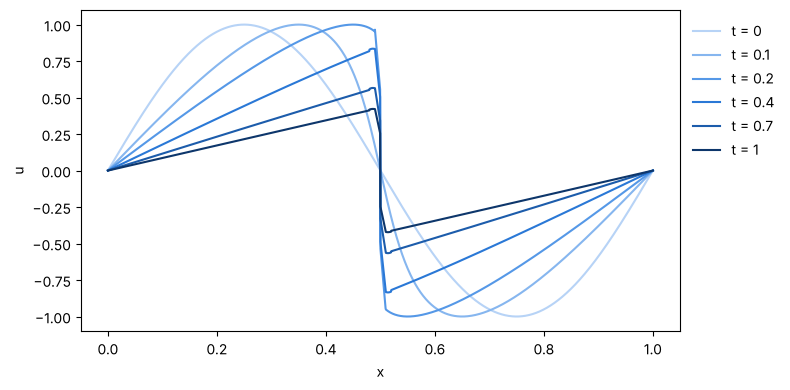

In [4]:
colors = ["#b7d3f6", "#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
plt.figure(figsize=(8, 4))
for color, (T, values) in zip(colors, snapshots.items()):
    plt.plot(xs, values, color=color, label=f"t = {T:g}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

**Before the shock** the exact solution is given implicitly by $u = \sin\left(2\pi(x - ut)\right)$, which we solve at every point by Newton's method and compare with the DG solution at $t = 0.1$.

In [5]:
t = 0.1
ue = np.sin(2 * np.pi * xs)
for k in range(50):
    s = 2 * np.pi * (xs - ue * t)
    ue -= (ue - np.sin(s)) / (1 + 2 * np.pi * t * np.cos(s))
print("maximum error at t = 0.1:", np.max(np.abs(snapshots[0.1] - ue)))

maximum error at t = 0.1: 0.00010160901355528467


**Without the limiter.** The same computation with `limiter=None` up to $t = 1$. Away from the shock the two solutions agree. Next to it, the solution without the limiter oscillates.

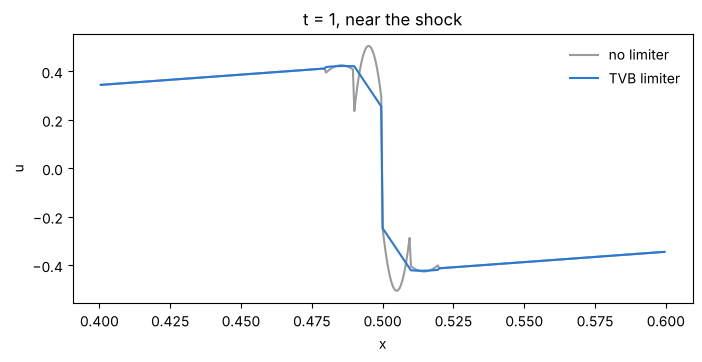

In [6]:
w2 = fd.Function(V)
w2.project(lambda x: np.sin(2 * np.pi * x))
R2 = fd.form(0.5 * w2**2 * D(v) * dx
             - (avg(0.5 * w2**2) + 0.5 * fd.max_value(fd.abs(w2('-')), fd.abs(w2('+'))) * jump(w2)) * jump(v) * dS)
rk2 = fd.SSPRK(M, R2, dt, order=3)
for n in range(round(1.0 / dt)):
    rk2.step(w2)

near = (xs > 0.4) & (xs < 0.6)
plt.figure(figsize=(8, 3.5))
plt.plot(xs[near], w2(xs[near]), color="#9a9a9a", label="no limiter")
plt.plot(xs[near], snapshots[1.0][near], color="#2a78d6", label="TVB limiter")
plt.title("t = 1, near the shock"); plt.xlabel("x"); plt.ylabel("u"); plt.legend(frameon=False)
plt.show()